In [ ]:
# 1. Recarrega os arquivos .py automaticamente sempre que forem alterados
%load_ext autoreload
%autoreload 2

# 2. Adiciona a pasta raiz do projeto ao caminho do Python
import sys

sys.path.append("..")

# 3. Importa os módulos e funções
from src.audio.chroma import extract_chroma

from src.audio.pitch import (
    extract_f0_pyin,
    show_spectrum,
    listen_beats,
    cut_vocal
)

from src.harmony.viterbi import suggest_chords_viterbi

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [4]:
import IPython.display as ipd
import librosa
import numpy as np
import matplotlib.pyplot as plt
import IPython.display as ipd
import pandas as pd
import soundfile as sf

## Teste com "Acima Do Sol"

In [5]:
y, sr = librosa.load('../data/audio-segment1-acima-do-sol-lead.mp3')
listen_beats(y, sr, 92, anacruse_beats=1.0)

c:\Users\Cliente\Documentos\Projeto_de_pesquisa\.venv-1\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
time, frequency, confident = extract_f0_pyin(y, sr)

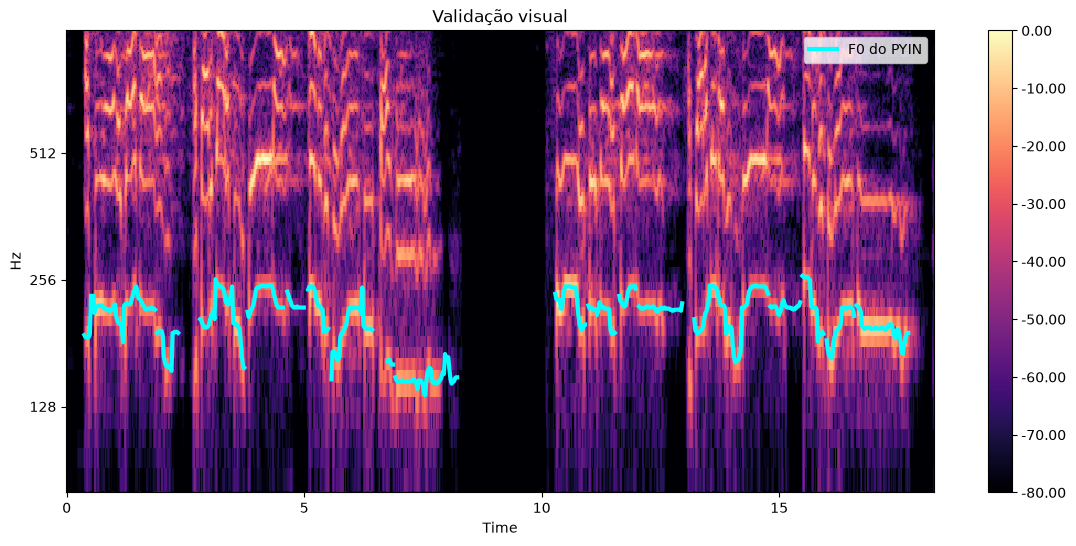

In [9]:
show_spectrum(time, frequency, confident, 0, y, sr)

In [ ]:
BPM = 92
df_compassos = extract_chroma(
    time,
    frequency,
    confident,
    BPM,
    tom='G',
    conf_thresh=0,
    quantizar_para_tom=True
)

print(df_compassos)

   compasso  tempo_inicio  tempo_fim  \
0         1          0.00       2.61   
1         2          2.61       5.22   
2         3          5.22       7.83   
3         4          7.83      10.43   
4         5         10.43      13.04   
5         6         13.04      15.65   
6         7         15.65      18.26   

                                              chroma nota_dominante  
0  [0.0, 0.0, 0.0, 0.0, 0.030303030303030304, 0.0...              A  
1  [0.0136986301369863, 0.0, 0.0, 0.0, 0.01369863...              B  
2  [0.0, 0.0, 0.40963855421686746, 0.0, 0.1204819...              D  
3  [0.0, 0.0, 0.6666666666666666, 0.0, 0.2, 0.0, ...              D  
4  [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0315789473684...              A  
5  [0.08888888888888889, 0.0, 0.0, 0.0, 0.0666666...              A  
6  [0.0, 0.0, 0.0, 0.0, 0.05, 0.0, 0.175, 0.5, 0....              G  


In [ ]:
acordes, caminho, funcoes = suggest_chords_viterbi(
  df_compassos, 
  tom_raiz='G', 
  tamanho_bloco=2, 
  permitir_diminutos=False,
  custo_repouso_final=0.0
)

df_compassos['acorde'] = acordes
df_compassos['funcao'] = df_compassos['acorde'].map(funcoes)

print(df_compassos[['compasso', 'nota_dominante', 'acorde', 'funcao']])

   compasso nota_dominante acorde funcao
0         1              A      D      D
1         2              B      G      T
2         3              D      D      D
3         4              D     Bm      T
4         5              A     Am     SD
5         6              A      D      D
6         7              G      G      T


## Teste com "Flores"

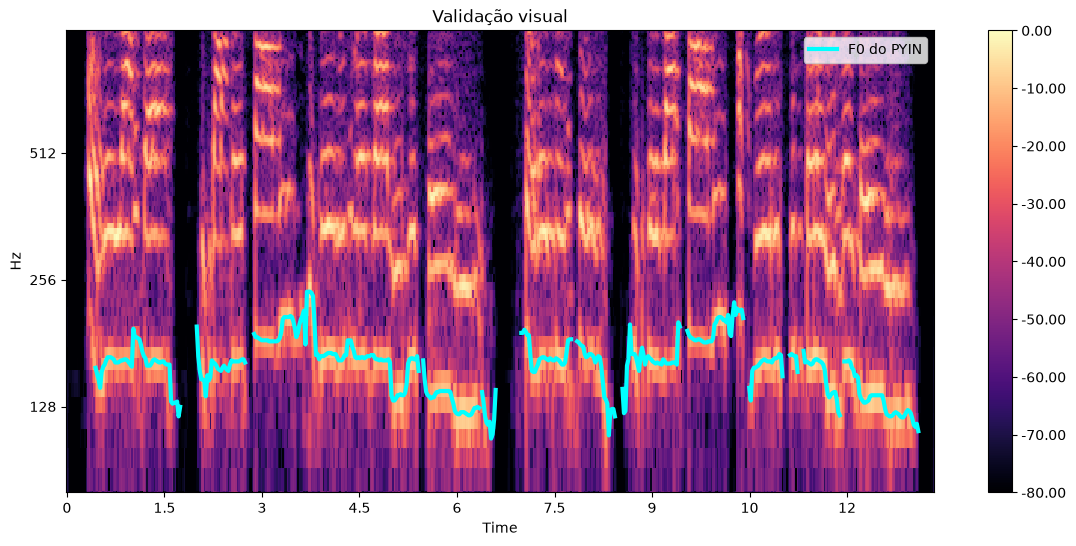

In [ ]:
y, sr = librosa.load('../data/Flores_segment1.mp3')
time, frequency, confidence = extract_f0_pyin(y, sr)
show_spectrum(time, frequency, confidence, 0, y, sr)
BPM=144
listen_beats(y, sr, BPM, anacruse_beats=1.25)

In [ ]:
df_compassos = extract_chroma(
    time, 
    frequency, 
    confidence, 
    BPM,
    tom='E',
    anacruse_beats=1.25,
    quantizar_para_tom=True
)

print(df_compassos)

   compasso  tempo_inicio  tempo_fim  \
0         1          0.52       2.19   
1         2          2.19       3.85   
2         3          3.85       5.52   
3         4          5.52       7.19   
4         5          7.19       8.85   
5         6          8.85      10.52   
6         7         10.52      12.19   
7         8         12.19      13.85   

                                              chroma nota_dominante  
0  [0.0, 0.020833333333333332, 0.0, 0.16666666666...              E  
1  [0.0, 0.0, 0.0, 0.16363636363636364, 0.2727272...             F#  
2  [0.0, 0.12962962962962962, 0.0, 0.018518518518...              E  
3  [0.0, 0.4, 0.0, 0.05, 0.025, 0.0, 0.05, 0.0, 0...              B  
4  [0.0, 0.02040816326530612, 0.0, 0.102040816326...              E  
5  [0.0, 0.01639344262295082, 0.0, 0.0, 0.3770491...              E  
6  [0.0, 0.09433962264150944, 0.0, 0.188679245283...              E  
7  [0.0, 0.3448275862068966, 0.0, 0.0, 0.0, 0.0, ...              B  


In [ ]:
acordes, caminho, funcoes = suggest_chords_viterbi(
    df_compassos, 
    tom_raiz='E',
    tamanho_bloco=2
)

df_compassos['acorde'] = acordes
df_compassos['funcao'] = df_compassos['acorde'].map(funcoes)

print(df_compassos[['compasso', 'nota_dominante', 'acorde', 'funcao']])

   compasso nota_dominante acorde funcao
0         1              E      E      T
1         2             F#      E      T
2         3              E      A     SD
3         4              B      A     SD
4         5              E      E      T
5         6              E      E      T
6         7              E      A     SD
7         8              B      A     SD


## Teste com "Trem-Bala"

In [ ]:
y, sr = cut_vocal('./Dataset/Trem Bala - Ana Vilela - Voz.mp3', 94, 3, 6, anacruse_beats=1.75)
sf.write('./Dataset/Samples/Trem-Bala_segment1.mp3', y, sr)

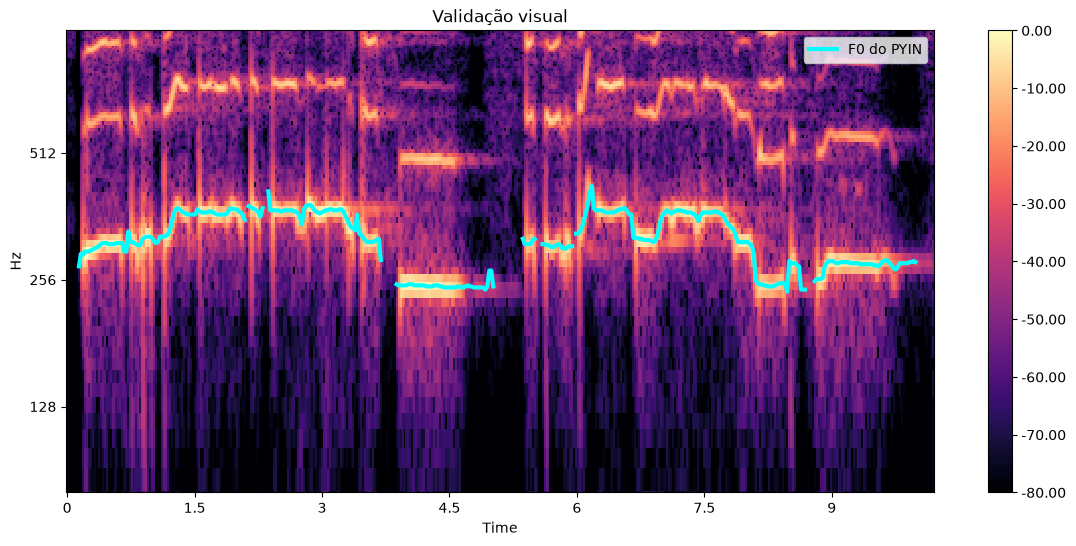

In [ ]:
audio_path = './Dataset/Samples/Trem-Bala_segment1.mp3'
y, sr = librosa.load(audio_path)
BPM = 94
time, frequency, confidence = extract_f0_pyin(y, sr)
show_spectrum(time, frequency, confidence, conf_thresh=0, y=y, sr=sr)
listen_beats(y, sr, BPM, anacruse_beats=1.75)

In [ ]:
df_compassos = extract_chroma(
    time, 
    frequency,
    confidence,
    BPM, 
    tom='B',
    anacruse_beats=1.75,
    quantizar_para_tom=False
)

print(df_compassos)

   compasso  tempo_inicio  tempo_fim  \
0         1          1.12       3.67   
1         2          3.67       6.22   
2         3          6.22       8.78   
3         4          8.78      11.33   

                                              chroma nota_dominante  
0  [0.0, 0.0, 0.0, 0.07476635514018691, 0.0841121...             F#  
1  [0.023529411764705882, 0.011764705882352941, 0...              B  
2  [0.009433962264150943, 0.05660377358490566, 0....             F#  
3  [0.07692307692307693, 0.9038461538461539, 0.0,...             C#  


In [ ]:
acordes, caminho, funcoes = suggest_chords_viterbi(
    df_compassos,
    tom_raiz='B',
    tamanho_bloco=1,
)

df_compassos['acorde'] = acordes
df_compassos['funcao'] = df_compassos['acorde'].map(funcoes)

print(df_compassos[['compasso', 'nota_dominante', 'acorde', 'funcao']])

   compasso nota_dominante acorde funcao
0         1             F#     F#      D
1         2              B      B      T
2         3             F#    D#m      T
3         4             C#    C#m     SD
